# DecodeLabs — Project 2: Data Classification Using AI

---

### Objective

Build a supervised classification model using the following pipeline:

- **Dataset**: Iris (150 samples, 3 classes, 4 features)
- **Algorithm**: K-Nearest Neighbors (KNN)
- **Evaluation**: Confusion Matrix and F1 Score

### IPO Pipeline


INPUT (Iris dataset + Feature Scaling)
  --> PROCESS (Train/Test Split + KNN algorithm)
    --> OUTPUT (Confusion Matrix + F1 Score)


## Step 1 — Importing Libraries

We import four groups of tools:

- **numpy / pandas**: numerical computation and tabular data manipulation
- **matplotlib / seaborn**: visualization of data distributions and model results
- **sklearn.datasets**: access to the built-in Iris benchmark dataset
- **sklearn.model_selection / preprocessing**: data splitting and feature scaling utilities
- **sklearn.neighbors**: the KNN classifier
- **sklearn.metrics**: accuracy, F1 score, confusion matrix, and classification report

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

## Step 2 — Loading and Exploring the Iris Dataset
The Iris dataset is a widely used classification dataset containing 150 flower samples from three species: Setosa, Versicolor, and Virginica, with 50 samples per species. Each sample is described by four numerical features: sepal length, sepal width, petal length, and petal width. These measurements enable machine learning algorithms to distinguish between the different species. Since the dataset is perfectly balanced, accuracy is a reliable evaluation metric. The F1-score is also commonly used, as it combines precision and recall into a single measure and provides a more comprehensive assessment of model performance.

In [13]:
# Load the Iris dataset
iris = load_iris()

# Build a pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset overview:")
print(f"  Number of samples : {df.shape[0]}")
print(f"  Number of features: {len(iris.feature_names)}")
print(f"  Classes           : {list(iris.target_names)}")
print(f"  Class distribution:\n{df['species'].value_counts()}")

print("\nFirst 10 rows:")
df.head(10)

Dataset overview:
  Number of samples : 150
  Number of features: 4
  Classes           : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First 10 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [14]:

print("Descriptive statistics:")
df.describe().round(2)

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


**Notice:**  sepal length ranges from 4.3 to 7.9 cm, while petal width ranges from 0.1 to 2.5 cm.

--> Features with larger values can dominate distance calculations in KNN, reducing the influence of smaller-scale features. Feature scaling puts all features on a similar scale, ensuring a fair contribution from each feature and improving model performance.

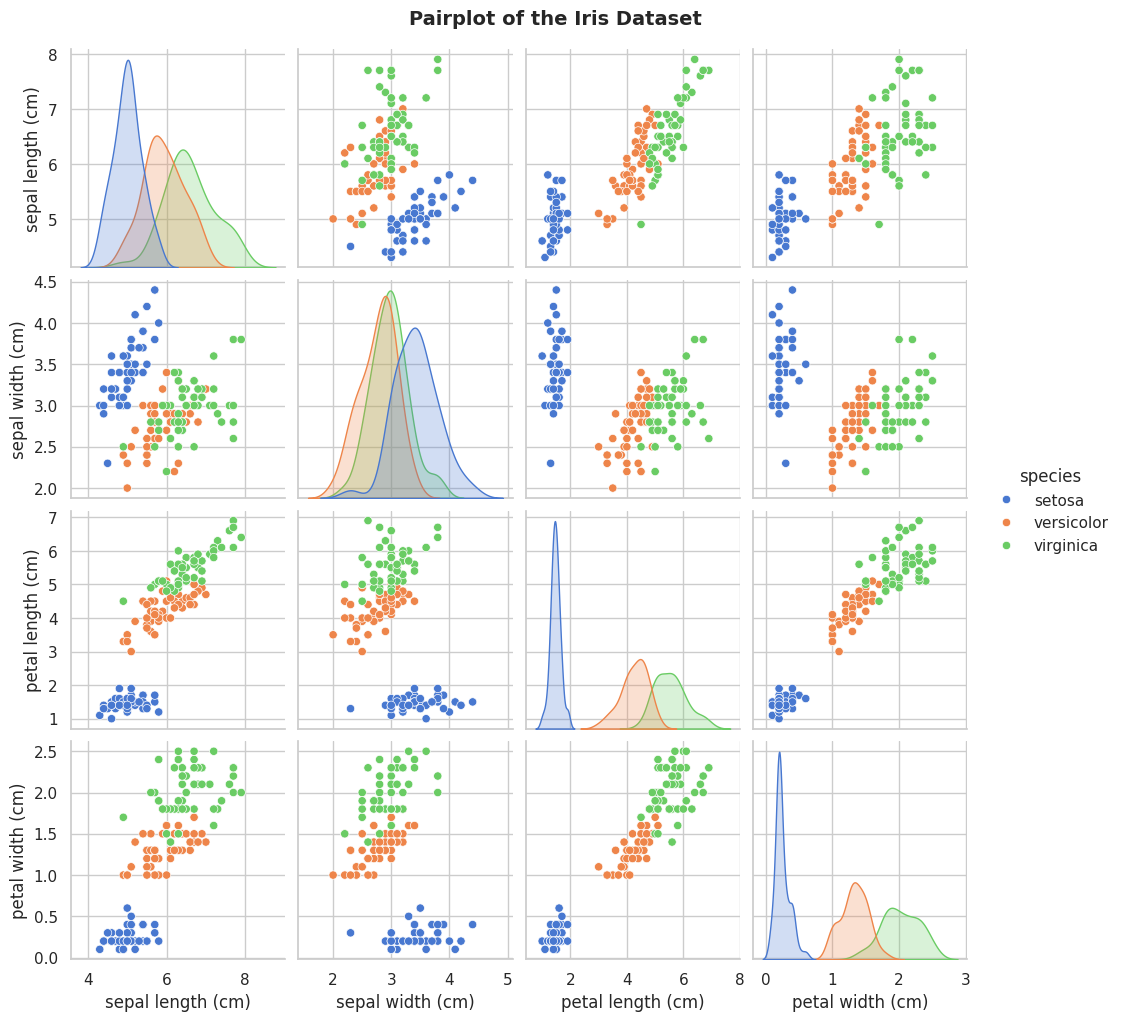

In [15]:
# Pairplot: visualize pairwise relationships between all features, colored by species.
sns.set_theme(style='whitegrid', palette='muted')
sns.pairplot(df, hue='species', diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of the Iris Dataset', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Interpretation:** The pairplot shows that petal length and petal width are the most informative features for classification. Setosa is clearly separated from the other species, while Versicolor and Virginica have slight overlap but remain mostly distinguishable. The strong positive correlation between petal length and petal width makes them particularly useful for identifying Iris species.

## Step 3 — Data Preparation: Feature Scaling and Train/Test Split

Two critical preprocessing steps are required before training KNN.

**1. Train/Test Split (80% / 20%)**

We divide the data into a training set and a test set. The model trains on the training
set and is evaluated exclusively on the test set.

**2. Feature Scaling (StandardScaler)**

KNN classifies a new point by computing its Euclidean distance to all training points.
If one feature has values in the thousands and another in the tenths, the large-scale
feature will completely dominate the distance and the model will effectively ignore the
smaller-scale feature.

StandardScaler resolves this by transforming each feature to have mean = 0 and variance = 1,
placing all features on equal footing.

In [16]:
# Separate features (X) from the target label (y)
X = iris.data    # Features: sepal_length, sepal_width, petal_length, petal_width
y = iris.target  # Target  : 0 = Setosa, 1 = Versicolor, 2 = Virginica

# Train/Test Split: 80% for training, 20% for evaluation
# random_state=42 guarantees reproducible results across different runs
# shuffle=True randomizes the order of samples to eliminate any ordering bias
# stratify=y ensures proportional class representation in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print("Train/Test Split result:")
print(f"  Training set : {X_train.shape[0]} samples (80%)")
print(f"  Test set     : {X_test.shape[0]} samples (20%)")

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling result (training set):")
print(f"  Mean per feature: {X_train_scaled.mean(axis=0).round(4)}")
print(f"  Std  per feature: {X_train_scaled.std(axis=0).round(4)}")
print("  Mean values are approximately 0 and std values approximately 1, confirming correct scaling.")

Train/Test Split result:
  Training set : 120 samples (80%)
  Test set     : 30 samples (20%)

Scaling result (training set):
  Mean per feature: [-0. -0.  0.  0.]
  Std  per feature: [1. 1. 1. 1.]
  Mean values are approximately 0 and std values approximately 1, confirming correct scaling.


## Step 4 — Finding the Optimal K (Elbow Method)

The K hyperparameter controls how many neighboring training points participate in the
majority vote when classifying a new sample.

- **K too small (e.g. K=1)**: The model bases its decision on a single neighbor. It becomes
  extremely sensitive to noise and outliers. This is overfitting: excellent performance on
  training data, poor generalization to new data.

- **K too large (e.g. K=100)**: The model averages over so many points that it loses
  sensitivity to local structure. This is underfitting: the decision boundary becomes
  too smooth and the model behaves like a naive majority classifier.

- **Optimal K**: Located at the "elbow" of the error curve — the point where increasing K
  further no longer significantly reduces the error rate. This is the best trade-off
  between bias and variance.


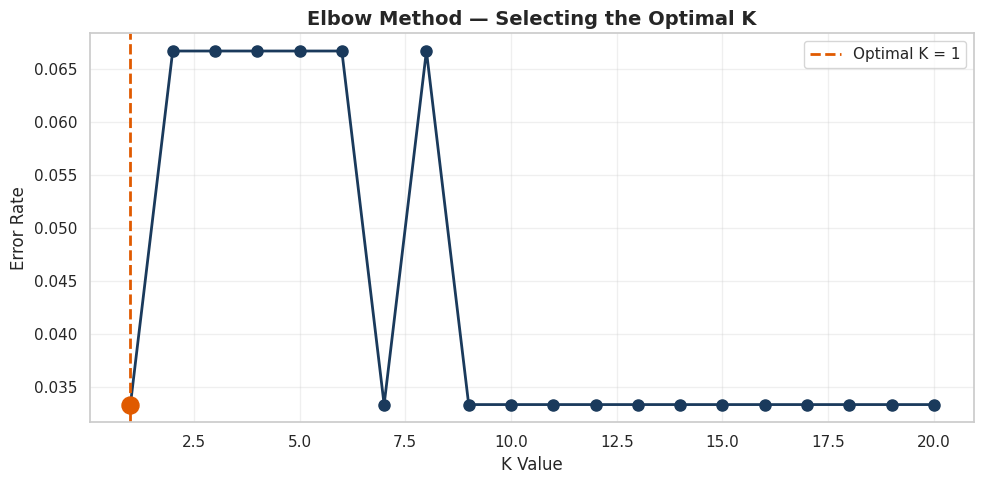

Optimal K: K = 1
Error rate at optimal K: 0.0333
This means the model correctly classifies 96.67% of test samples.


In [17]:
# Test K values from 1 to 20
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    preds_temp = knn_temp.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, preds_temp))

# Identify the optimal K: the value with the lowest error rate
best_k = error_rates.index(min(error_rates)) + 1

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, marker='o', color='#1a3a5c', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='#e05a00', linestyle='--', linewidth=2, label=f'Optimal K = {best_k}')
plt.scatter([best_k], [error_rates[best_k - 1]], color='#e05a00', s=150, zorder=5)
plt.title('Elbow Method — Selecting the Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal K: K = {best_k}")
print(f"Error rate at optimal K: {min(error_rates):.4f}")
print(f"This means the model correctly classifies {(1 - min(error_rates)) * 100:.2f}% of test samples.")

## Step 5 — Training the KNN Model

In [18]:
# Step 1 — Instantiate: create the KNN classifier with the optimal K
model = KNeighborsClassifier(n_neighbors=best_k)

# Step 2 — Fit: store the training data in memory (KNN is a lazy learner)
model.fit(X_train_scaled, y_train)

# Step 3 — Predict: classify each test sample by majority vote among K nearest neighbors
y_pred = model.predict(X_test_scaled)

print(f"KNN model ready with K = {best_k}.")
print(f"\nFirst 10 predictions vs. ground truth:")
comparison = pd.DataFrame({
    'Actual'   : [iris.target_names[i] for i in y_test[:10]],
    'Predicted': [iris.target_names[i] for i in y_pred[:10]],
    'Correct'  : ['YES' if r == p else 'NO' for r, p in zip(y_test[:10], y_pred[:10])]
})
print(comparison.to_string(index=False))

KNN model ready with K = 1.

First 10 predictions vs. ground truth:
    Actual  Predicted Correct
    setosa     setosa     YES
 virginica  virginica     YES
versicolor versicolor     YES
versicolor versicolor     YES
    setosa     setosa     YES
versicolor versicolor     YES
    setosa     setosa     YES
    setosa     setosa     YES
 virginica  virginica     YES
versicolor versicolor     YES


## Step 6 — Model Evaluation

We use three complementary evaluation tools to get a complete picture of model performance.

**Accuracy**: The fraction of all predictions that are correct. Reliable on balanced datasets.
On imbalanced datasets, a model can achieve 99% accuracy by always predicting the majority
class, which is why accuracy alone is never sufficient.

**Confusion Matrix**: A grid where each row represents the actual class and each column
represents the predicted class. The diagonal cells show correct predictions (true positives
and true negatives). Off-diagonal cells show errors. This reveals which specific classes
the model confuses with each other.

**Classification Report**: Per-class breakdown of three metrics:
- **Precision**: Among all samples the model predicted as class X, what fraction actually
  belong to class X? High precision = few false alarms.
- **Recall**: Among all samples that truly belong to class X, what fraction did the model
  correctly identify? High recall = few missed detections.
- **F1 Score**: The harmonic mean of precision and recall. It is 1.0 only when both
  precision and recall are 1.0. The harmonic mean penalizes extreme imbalances between the
  two more severely than an arithmetic mean would.

In [19]:
# Compute primary metrics
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average='weighted')

print("KNN MODEL RESULTS")
print(f"  Accuracy : {accuracy * 100:.2f}%")
print(f"  F1 Score : {f1:.4f}")

# The weighted F1 score weights each class by its number of true samples (support).
# On a perfectly balanced dataset, it equals the macro F1 score.
print("Full Classification Report (per class breakdown):")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

KNN MODEL RESULTS
  Accuracy : 96.67%
  F1 Score : 0.9666
Full Classification Report (per class breakdown):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



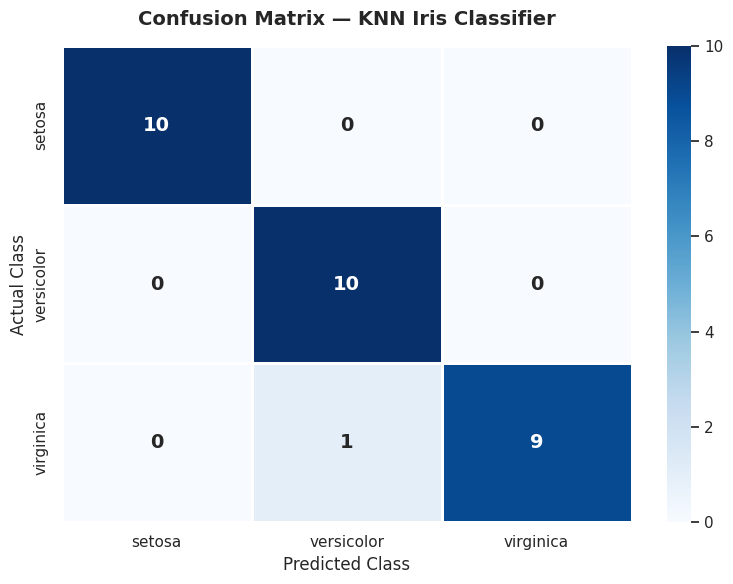

How to read this matrix:
  - Diagonal cells: correct predictions (true positives per class).
  - Off-diagonal cells: misclassifications.
  - Example: a value of 2 in row 'versicolor', column 'virginica' means
    2 actual versicolor flowers were incorrectly predicted as virginica.


In [20]:
# Confusion Matrix heatmap
# Each row = actual class. Each column = predicted class.
# Main diagonal (top-left to bottom-right) = correct predictions.
# Off-diagonal cells = misclassifications, showing which classes are confused.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Confusion Matrix — KNN Iris Classifier', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.show()

print("How to read this matrix:")
print("  - Diagonal cells: correct predictions (true positives per class).")
print("  - Off-diagonal cells: misclassifications.")
print("  - Example: a value of 2 in row 'versicolor', column 'virginica' means")
print("    2 actual versicolor flowers were incorrectly predicted as virginica.")

## Step 7 — Predicting on New, Unseen Data

After training, the model must classify
samples it has never encountered.

fit(): learns the parameters from the training data.

For example, with a scaler, it computes values like minimum, maximum, mean, and standard deviation.

transform(): uses these learned parameters to scale or modify the data.

fit_transform(): performs both steps at once (first fit(), then transform()).

In [21]:
# Three hypothetical iris flowers with measurements in centimeters
# Format: [sepal_length, sepal_width, petal_length, petal_width]
new_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Small petals — expected: Setosa
    [6.3, 3.3, 4.7, 1.6],  # Medium petals — expected: Versicolor
    [7.2, 3.0, 5.8, 1.6],  # Large petals — expected: Virginica
])

# Apply the same scaler fit on training data — only transform, no re-fitting
new_flowers_scaled = scaler.transform(new_flowers)

# Predict class labels and get probability estimates
predictions = model.predict(new_flowers_scaled)
probas      = model.predict_proba(new_flowers_scaled)

print("Predictions on new unseen flowers:")
for i, (flower, pred) in enumerate(zip(new_flowers, predictions)):
    confidence = probas[i][pred] * 100
    votes = int(confidence / 100 * best_k)
    print(f"  Flower {i+1}: {flower}")
    print(f"    Predicted class : {iris.target_names[pred].upper()}")
    print(f"    Confidence      : {confidence:.0f}%  ({votes} out of {best_k} neighbors voted for this class)")
    print()


Predictions on new unseen flowers:
  Flower 1: [5.1 3.5 1.4 0.2]
    Predicted class : SETOSA
    Confidence      : 100%  (1 out of 1 neighbors voted for this class)

  Flower 2: [6.3 3.3 4.7 1.6]
    Predicted class : VERSICOLOR
    Confidence      : 100%  (1 out of 1 neighbors voted for this class)

  Flower 3: [7.2 3.  5.8 1.6]
    Predicted class : VIRGINICA
    Confidence      : 100%  (1 out of 1 neighbors voted for this class)



## Step 8 — Comparing Multiple Classification Algorithms

To validate our choice of KNN and understand the strengths of different approaches,
we benchmark five classifiers on the exact same preprocessed data.

| Algorithm | Core principle |
|---|---|
| KNN | Majority vote among K nearest neighbors in feature space (distance-based) |
| Decision Tree | Recursive feature threshold splits forming a binary tree (rule-based) |
| SVM | Maximum-margin hyperplane separating classes in a high-dimensional space |
| Logistic Regression | Linear model that estimates class probabilities using the logistic function |
| Naive Bayes | Bayes theorem with a strong independence assumption between features |

All models receive the same scaled training and test sets, ensuring a fair comparison
where performance differences reflect algorithm behavior rather than data preparation differences.

Algorithm Comparison Results:
                Accuracy F1 Score
Algorithm                        
KNN (optimal K)   96.67%   0.9666
Decision Tree     93.33%   0.9333
SVM               96.67%   0.9666
Logistic Reg.     93.33%   0.9333
Naive Bayes       96.67%   0.9666


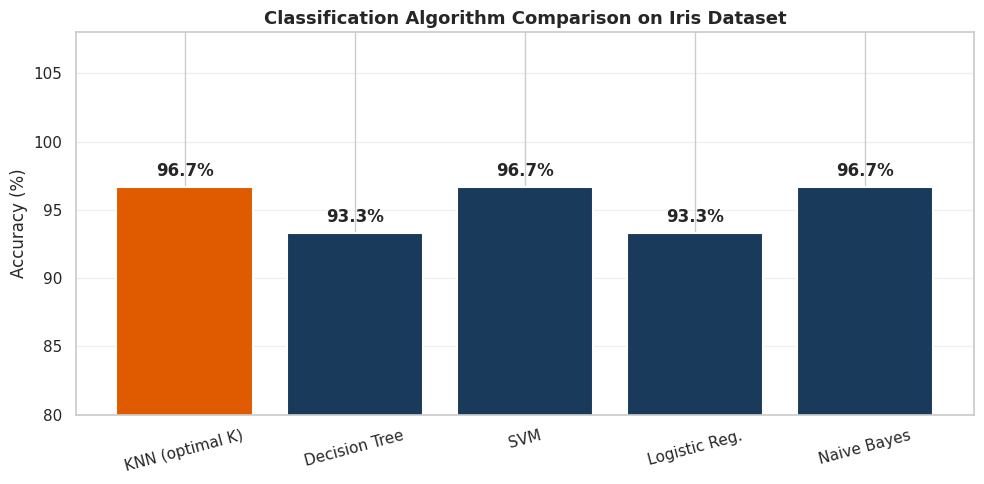

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Define all classifiers
classifiers = {
    'KNN (optimal K)': KNeighborsClassifier(n_neighbors=best_k),
    'Decision Tree'  : DecisionTreeClassifier(random_state=42),
    'SVM'            : SVC(random_state=42),
    'Logistic Reg.'  : LogisticRegression(max_iter=200, random_state=42),
    'Naive Bayes'    : GaussianNB(),
}

# Train each classifier on the same training data and evaluate on the same test data
benchmark = []
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    benchmark.append({
        'Algorithm': name,
        'Accuracy' : f"{accuracy_score(y_test, preds) * 100:.2f}%",
        'F1 Score' : f"{f1_score(y_test, preds, average='weighted'):.4f}"
    })

results_df = pd.DataFrame(benchmark).set_index('Algorithm')
print("Algorithm Comparison Results:")
print(results_df.to_string())

# Bar chart of accuracy by algorithm (KNN highlighted in orange)
accuracies = [float(r['Accuracy'].replace('%', '')) for r in benchmark]
names      = [r['Algorithm'] for r in benchmark]
colors     = ['#e05a00' if n == 'KNN (optimal K)' else '#1a3a5c' for n in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, accuracies, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.ylim(80, 108)
plt.title('Classification Algorithm Comparison on Iris Dataset', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation of Results

All five algorithms perform well on this dataset .

KNN, SVM, and Naive Bayes perform better because the Iris dataset has clear and simple patterns, especially between Setosa and the other species.

KNN works well because it classifies a flower based on its closest neighbors, which is very effective when similar samples are grouped together. SVM performs strongly because it finds the best boundary that separates the classes, even when there is a small overlap. Naive Bayes also performs well because it assumes feature independence and can still model the data effectively in this simple dataset.

Decision Tree and Logistic Regression perform slightly worse because they are less flexible. Logistic Regression assumes a mostly linear relationship, which does not fully capture small overlaps between classes. A single Decision Tree can also be sensitive to small changes in data and may not generalize as well.

Overall, the dataset is simple and well-structured, so models that adapt easily to data patterns achieve the best results.
